# TITANIC DATASET ANALYSIS

***Perform Data Cleaning and Exploratory Data Analysis (EDA) on a dataset of your choice, such as the Titanic dataset from Kaggle. Explore the relationships between variables and identify patterns and trends in the data***

# Importing Essential Libraries:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Loading The Data

In [2]:
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

# Data Preprocessing

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
train.shape

(891, 12)

In [6]:
test.shape

(418, 11)

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
train.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [10]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

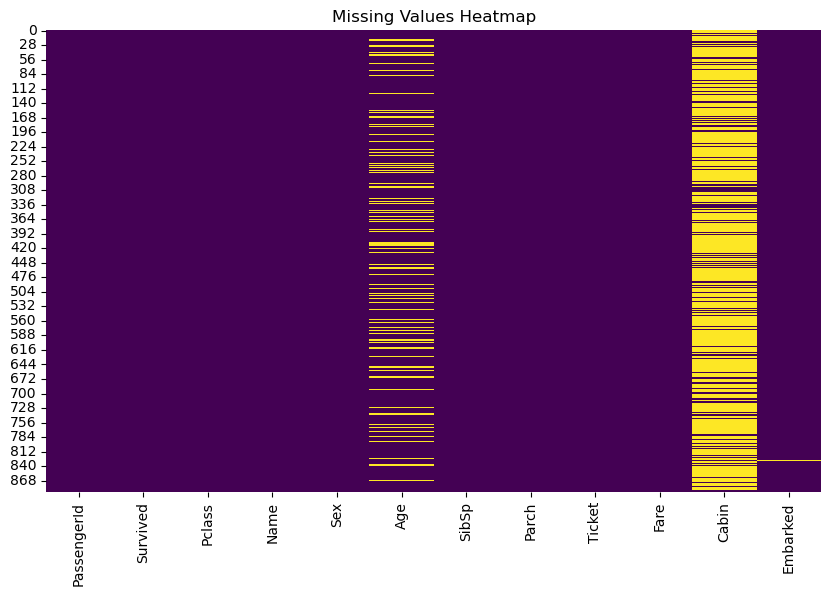

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(train.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [12]:
train['Age'].fillna(train['Age'].median(), inplace=True)

In [13]:
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

In [14]:
train.drop('Cabin', axis=1, inplace=True)

In [15]:
train.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [16]:
train.duplicated().sum()

0

# Exploratory Data Analysis

## Survival Distribution

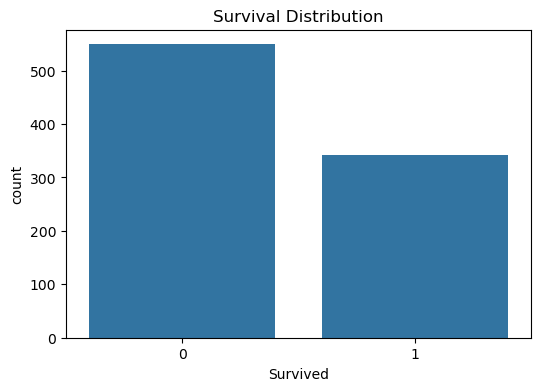

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train)
plt.title("Survival Distribution")
plt.show()

## Survival by Gender

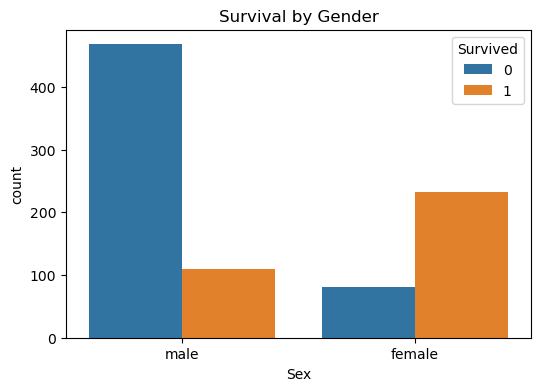

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', hue='Survived', data=train)
plt.title("Survival by Gender")
plt.show()

## Survival by Passenger Class

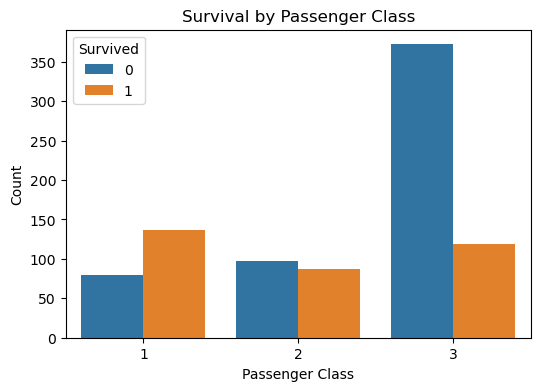

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Pclass', hue='Survived', data=train)
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

## Age Distribution

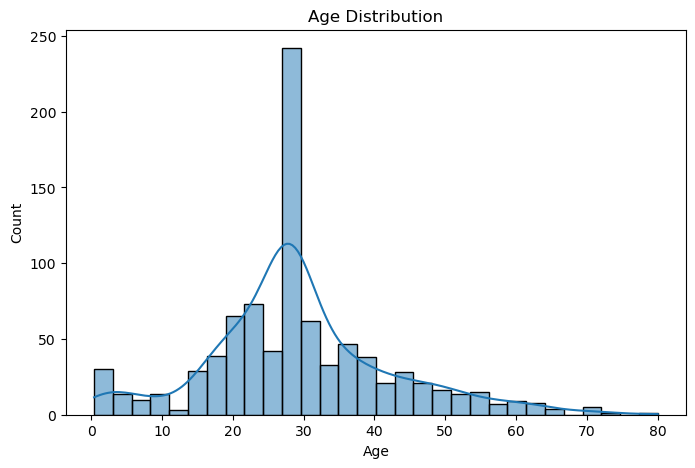

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(train['Age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

## Fare Distribution

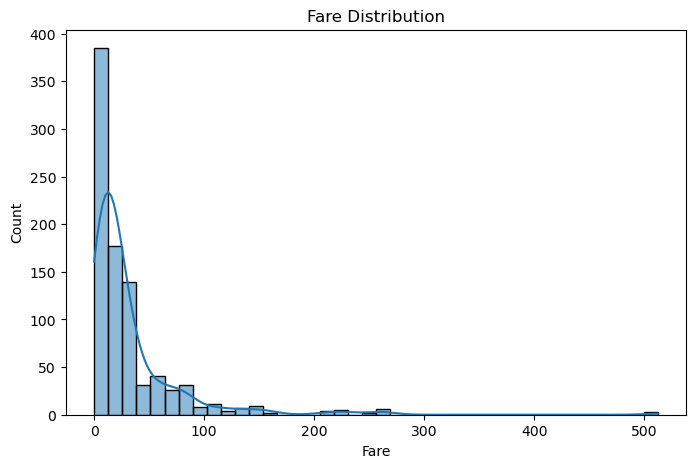

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(train['Fare'], bins=40, kde=True)

plt.title("Fare Distribution")
plt.show()

## Survival by Embarkation Port

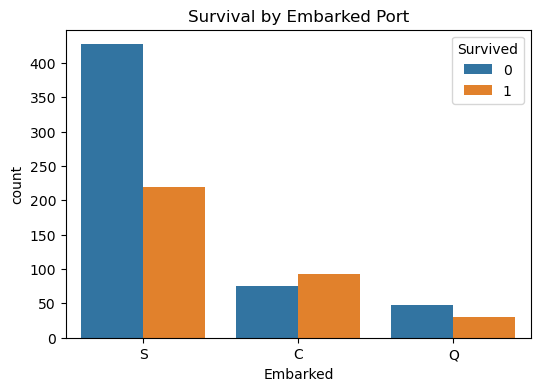

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x='Embarked', hue='Survived', data=train)

plt.title("Survival by Embarked Port")
plt.show()

## Correlation Analysis

In [23]:
eda_df = train.copy()

eda_df['Sex'] = eda_df['Sex'].map({'male':0, 'female':1})
eda_df['Embarked'] = eda_df['Embarked'].map({'S':0, 'C':1, 'Q':2})

# Correlation Matrix

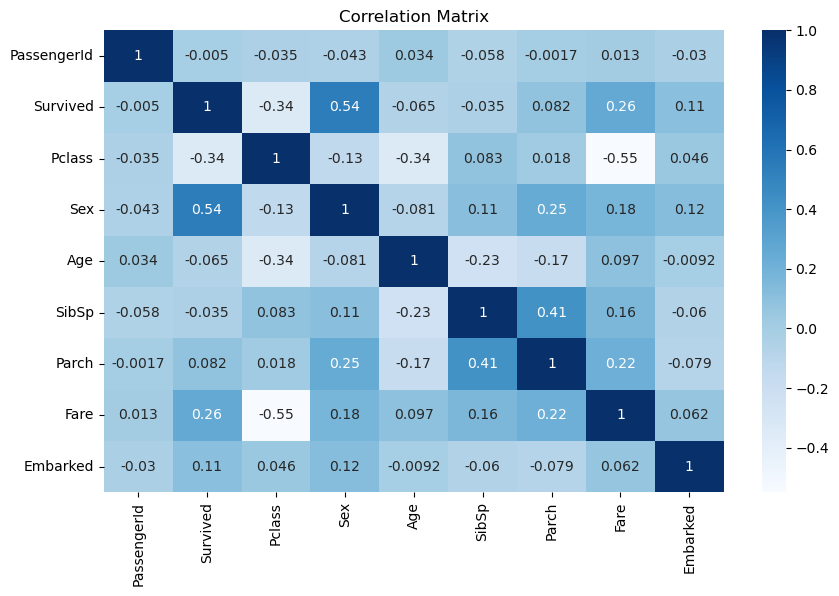

In [24]:
plt.figure(figsize=(10,6))

sns.heatmap(
    eda_df.corr(numeric_only=True),
    annot=True,
    cmap='Blues')

plt.title("Correlation Matrix")
plt.show()

## Pairplot

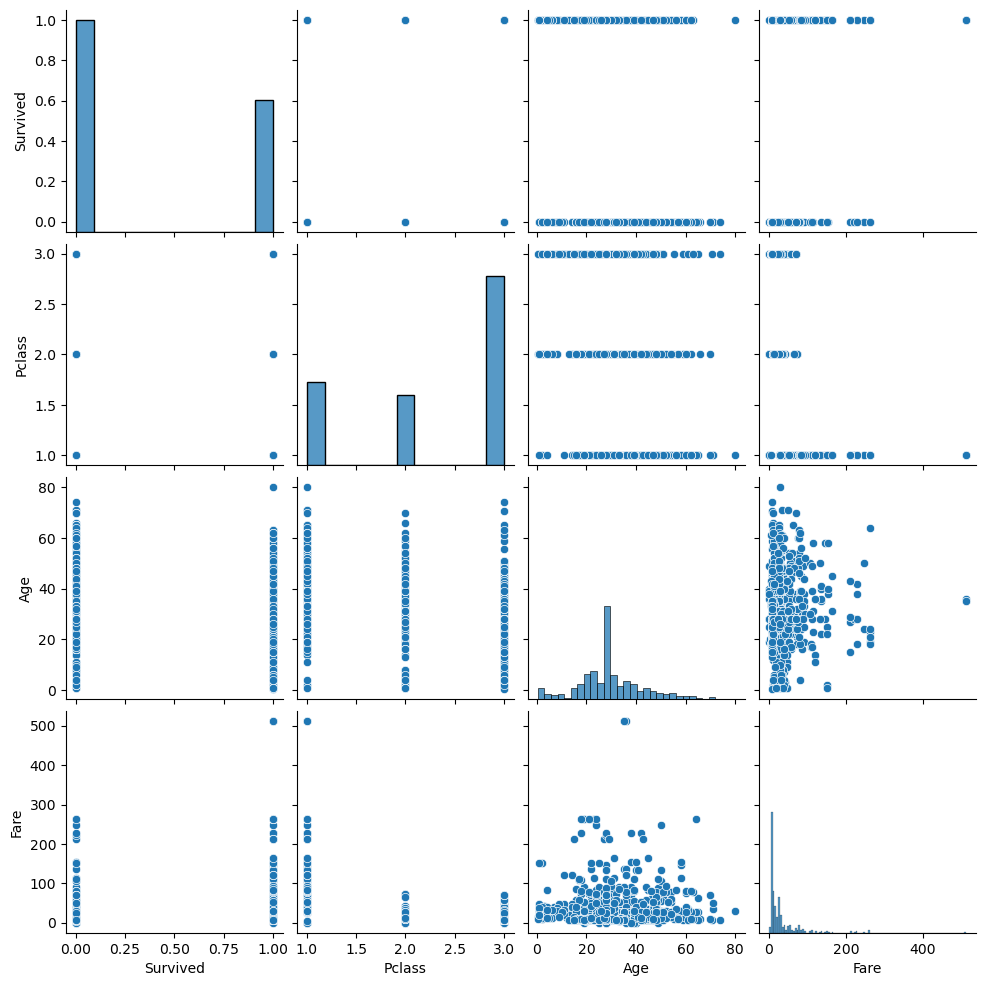

In [25]:
sns.pairplot(train[['Survived','Pclass','Age','Fare']])
plt.show()